# **MLPS - Final Project Data EDA**

-- Nerin Wang<br>
-- qiushiw<br>
-- Mar 20th 2026

In [1]:
# ============== META VARIABLES ==============
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from math import sqrt
import warnings
import plotly.graph_objects as go
import seaborn as sns
import plotly.express as px

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Data paths
DATA_DIR = "data/"
RESULTS_DIR = "results/"
os.makedirs(RESULTS_DIR, exist_ok=True)

TRAIN_PATH = os.path.join(DATA_DIR, "train.nc")

# The test_24h_demo.nc and test_48h_demo.nc are just demo files, so the outages in those files are just noise
# TEST_24H_PATH = os.path.join(DATA_DIR, "test_24h.nc")
# TEST_48H_PATH = os.path.join(DATA_DIR, "test_48h.nc")
TEST_24H_PATH = os.path.join(DATA_DIR, "test_24h_demo.nc")
TEST_48H_PATH = os.path.join(DATA_DIR, "test_48h_demo.nc")

# Model parameters
VALIDATION_SPLIT = 0.2  # Use last 20% of training data for validation

# SARIMAX parameters
SARIMAX_ORDER = (1, 0, 1)  # (p, d, q)

# Seq2Seq parameters
SEQ_LEN = 24       # Lookback window (hours) for the seq2seq model
BATCH_SIZE = 64
EPOCHS = 5
LEARNING_RATE = 1e-3
HIDDEN_DIM = 64
NUM_LAYERS = 1

# Set device for PyTorch
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Configuration loaded successfully!")
print(f"Random Seed: {RANDOM_SEED}")
print(f"Device: {DEVICE}")
print(f"Data Directory: {DATA_DIR}")
print(f"Results Directory: {RESULTS_DIR}")

Configuration loaded successfully!
Random Seed: 42
Device: cpu
Data Directory: data/
Results Directory: results/


In [2]:
# Load datasets
ds_train = xr.open_dataset(TRAIN_PATH)
ds_test_24h = xr.open_dataset(TEST_24H_PATH)
ds_test_48h = xr.open_dataset(TEST_48H_PATH)

In [3]:
ds_train.head()

<xarray.Dataset>
Dimensions:    (location: 5, timestamp: 5, feature: 5)
Coordinates:
  * location   (location) object '26001' '26003' '26005' '26007' '26009'
  * feature    (feature) object 'SBT113' 'SBT114' 'SBT123' 'SBT124' 'aod'
  * timestamp  (timestamp) datetime64[ns] 2023-04-01 ... 2023-04-01T04:00:00
    state      (location) object ...
Data variables:
    tracked    (location, timestamp) float64 ...
    out        (location, timestamp) float64 ...
    weather    (location, timestamp, feature) float64 ...
Attributes:
    time_start:  2022-01-01T00:00:00
    time_end:    2022-01-31T23:00:00
    time_now:    2025-07-08T14:59:10

For full data EDA process, conduct only on the training dataset:

1. feature and description mappings:

In [4]:
features = ds_train.coords["feature"].values.tolist()
print("Number of features:", len(features))
print(features)

Number of features: 109
['SBT113', 'SBT114', 'SBT123', 'SBT124', 'aod', 'bgrun', 'blh', 'cape', 'cape_1', 'cfnsf', 'cfrzr', 'cicep', 'cin', 'cnwat', 'cpofp', 'crain', 'csnow', 'd2m', 'fricv', 'frzr', 'fsr', 'gflux', 'gh', 'gh_1', 'gh_2', 'gh_3', 'gh_4', 'gh_5', 'gh_6', 'gh_7', 'gust', 'hail', 'hail_1', 'hail_2', 'hcc', 'ishf', 'lai', 'layth', 'lcc', 'lftx', 'lftx4', 'lsm', 'ltng', 'max_10si', 'mcc', 'mdens', 'mslma', 'mstav', 'orog', 'pcdb', 'plpl', 'prate', 'pres', 'pres_1', 'pres_2', 'pt', 'pwat', 'r', 'r2', 'r_1', 'refc', 'refd', 'refd_1', 'sde', 'sdlwrf', 'sdswrf', 'sdwe', 'sdwe_1', 'sh2', 'siconc', 'slhtf', 'snowc', 'sp', 'ssrun', 'sulwrf', 'suswrf', 't', 't2m', 'tcc', 'tcc_1', 'tcoli', 'tcolw', 'tp', 'u', 'u10', 'unknown', 'unknown_1', 'unknown_2', 'unknown_3', 'unknown_4', 'unknown_5', 'unknown_6', 'unknown_7', 'unknown_8', 'unknown_9', 'ustm', 'v', 'v10', 'vbdsf', 'vddsf', 'veg', 'veril', 'vgtyp', 'vis', 'vstm', 'vucsh', 'vvcsh', 'wz', 'wz_1']


In [5]:
feature_description = {
    "SBT113": "Satellite brightness temperature (channel 113)",
    "SBT114": "Satellite brightness temperature (channel 114)",
    "SBT123": "Satellite brightness temperature (channel 123)",
    "SBT124": "Satellite brightness temperature (channel 124)",
    "aod": "Aerosol optical depth",
    "bgrun": "Baseflow groundwater runoff",
    "blh": "Boundary layer height",
    "cape": "Convective available potential energy",
    "cape_1": "Lagged CAPE (previous timestep)",
    "cfnsf": "Convective snowfall",
    "cfrzr": "Convective freezing rain",
    "cicep": "Convective ice pellets",
    "cin": "Convective inhibition",
    "cnwat": "Column-integrated cloud water",
    "cpofp": "Convective precipitation of frozen precipitation",
    "crain": "Convective rain",
    "csnow": "Convective snow",
    "d2m": "2-meter dew point temperature",
    "fricv": "Friction velocity",
    "frzr": "Freezing rain",
    "fsr": "Forecast surface roughness",
    "gflux": "Ground heat flux",
    "gh": "Geopotential height",
    "gh_1": "Geopotential height (level 1)",
    "gh_2": "Geopotential height (level 2)",
    "gh_3": "Geopotential height (level 3)",
    "gh_4": "Geopotential height (level 4)",
    "gh_5": "Geopotential height (level 5)",
    "gh_6": "Geopotential height (level 6)",
    "gh_7": "Geopotential height (level 7)",
    "gust": "Wind gust speed",
    "hail": "Hail occurrence",
    "hail_1": "Lagged hail occurrence",
    "hail_2": "Further lagged hail occurrence",
    "hcc": "High cloud cover",
    "ishf": "Instantaneous surface heat flux",
    "lai": "Leaf area index",
    "layth": "Layer thickness",
    "lcc": "Low cloud cover",
    "lftx": "Lifted index",
    "lftx4": "Lifted index (variant or level 4)",
    "lsm": "Land-sea mask",
    "ltng": "Lightning activity",
    "max_10si": "Maximum 10-meter wind speed",
    "mcc": "Medium cloud cover",
    "mdens": "Mean density",
    "mslma": "Mean sea level pressure anomaly",
    "mstav": "Mean surface temperature (average)",
    "orog": "Orography (terrain elevation)",
    "pcdb": "Potential convective downdraft buoyancy",
    "plpl": "Potential latent heat flux",
    "prate": "Precipitation rate",
    "pres": "Pressure",
    "pres_1": "Pressure (lagged or different level)",
    "pres_2": "Pressure (second lag or level)",
    "pt": "Potential temperature",
    "pwat": "Precipitable water",
    "r": "Relative humidity",
    "r2": "Relative humidity squared or variant",
    "r_1": "Lagged relative humidity",
    "refc": "Composite radar reflectivity",
    "refd": "Radar reflectivity (differential)",
    "refd_1": "Lagged radar reflectivity",
    "sde": "Snow depth",
    "sdlwrf": "Surface downward longwave radiation flux",
    "sdswrf": "Surface downward shortwave radiation flux",
    "sdwe": "Snow water equivalent",
    "sdwe_1": "Lagged snow water equivalent",
    "sh2": "Specific humidity",
    "siconc": "Sea ice concentration",
    "slhtf": "Surface latent heat flux",
    "snowc": "Snow cover",
    "sp": "Surface pressure",
    "ssrun": "Surface runoff",
    "sulwrf": "Surface upward longwave radiation flux",
    "suswrf": "Surface upward shortwave radiation flux",
    "t": "Temperature (general atmospheric)",
    "t2m": "2-meter temperature",
    "tcc": "Total cloud cover",
    "tcc_1": "Lagged total cloud cover",
    "tcoli": "Total column ice",
    "tcolw": "Total column water",
    "tp": "Total precipitation",
    "u": "Zonal wind component",
    "u10": "10-meter zonal wind",
    "unknown": "Unknown variable (not documented)",
    "unknown_1": "Unknown variable (variant 1)",
    "unknown_2": "Unknown variable (variant 2)",
    "unknown_3": "Unknown variable (variant 3)",
    "unknown_4": "Unknown variable (variant 4)",
    "unknown_5": "Unknown variable (variant 5)",
    "unknown_6": "Unknown variable (variant 6)",
    "unknown_7": "Unknown variable (variant 7)",
    "unknown_8": "Unknown variable (variant 8)",
    "unknown_9": "Unknown variable (variant 9)",
    "ustm": "U-component storm motion",
    "v": "Meridional wind component",
    "v10": "10-meter meridional wind",
    "vbdsf": "Vertical diffusion shortwave flux",
    "vddsf": "Vertical diffusion downward shortwave flux",
    "veg": "Vegetation fraction",
    "veril": "Vertical integrated liquid water",
    "vgtyp": "Vegetation type",
    "vis": "Visibility",
    "vstm": "V-component storm motion",
    "vucsh": "Vertical wind shear (u component)",
    "vvcsh": "Vertical wind shear (v component)",
    "wz": "Vertical velocity",
    "wz_1": "Lagged vertical velocity"
}

feature_names = ds_train.coords["feature"].values

feature_desc_list = [
    feature_description.get(f, "Unknown feature") 
    for f in feature_names
]

ds_train = ds_train.assign_coords(
    feature_desc=("feature", feature_desc_list)
)

for f, d in zip(
    ds_train.feature.values,
    ds_train.feature_desc.values
):
    print(f"{f}: {d}")

SBT113: Satellite brightness temperature (channel 113)
SBT114: Satellite brightness temperature (channel 114)
SBT123: Satellite brightness temperature (channel 123)
SBT124: Satellite brightness temperature (channel 124)
aod: Aerosol optical depth
bgrun: Baseflow groundwater runoff
blh: Boundary layer height
cape: Convective available potential energy
cape_1: Lagged CAPE (previous timestep)
cfnsf: Convective snowfall
cfrzr: Convective freezing rain
cicep: Convective ice pellets
cin: Convective inhibition
cnwat: Column-integrated cloud water
cpofp: Convective precipitation of frozen precipitation
crain: Convective rain
csnow: Convective snow
d2m: 2-meter dew point temperature
fricv: Friction velocity
frzr: Freezing rain
fsr: Forecast surface roughness
gflux: Ground heat flux
gh: Geopotential height
gh_1: Geopotential height (level 1)
gh_2: Geopotential height (level 2)
gh_3: Geopotential height (level 3)
gh_4: Geopotential height (level 4)
gh_5: Geopotential height (level 5)
gh_6: Geopot

2. timestamp check：

In [6]:
print("Minimum timestamp:", ds_train.timestamp.min().values)
print("Maximum timestamp:", ds_train.timestamp.max().values)
print("The length of timestamps is", len(ds_train.timestamp))

Minimum timestamp: 2023-04-01T00:00:00.000000000
Maximum timestamp: 2023-06-30T00:00:00.000000000
The length of timestamps is 2161


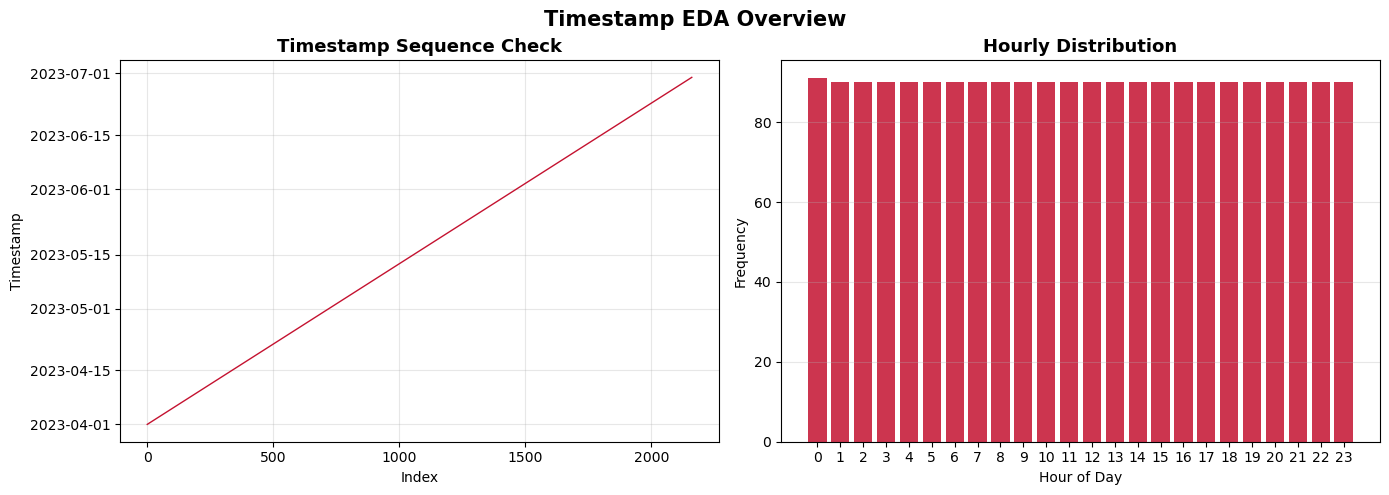

In [7]:
#hourly patterns and data distribution over time:

ts = pd.to_datetime(ds_train.timestamp.values)

hour_counts = pd.Series(ts).dt.hour.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Timestamp sequence ---
axes[0].plot(ts, color="#C41230", linewidth=1)
axes[0].set_title("Timestamp Sequence Check", fontsize=13, weight='bold')
axes[0].set_xlabel("Index")
axes[0].set_ylabel("Timestamp")
axes[0].grid(alpha=0.3)

# --- Right: Hourly histogram ---
axes[1].bar(hour_counts.index, hour_counts.values, color="#C41230", alpha=0.85)
axes[1].set_title("Hourly Distribution", fontsize=13, weight='bold')
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Frequency")
axes[1].set_xticks(range(24))
axes[1].grid(axis='y', alpha=0.3)


fig.suptitle("Timestamp EDA Overview", fontsize=15, weight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.88)

plt.show()

In [8]:
time_diff = ts.diff().dropna()

# Frequency check
if (time_diff == pd.Timedelta(hours=1)).all():
    print("Timestamp frequency is consistent: hourly")
else:
    print("Irregular timestamp intervals detected")
    print(time_diff.value_counts())

# Missing timestamps
full_range = pd.date_range(start=ts.min(), end=ts.max(), freq="h")
missing_timestamps = full_range.difference(pd.DatetimeIndex(ts))

# Timestamp
ts = pd.Series(ds_train.timestamp.values)
print("Timestamp sorted:", ts.is_monotonic_increasing)
print("Duplicate timestamps:", ts.duplicated().sum())

print("Missing timestamps:", len(missing_timestamps))

Timestamp frequency is consistent: hourly
Timestamp sorted: True
Duplicate timestamps: 0
Missing timestamps: 0


In [9]:
print("Weather NaN rate:", ds_train["weather"].isnull().mean().item())
print("Tracked NaN rate:", ds_train["tracked"].isnull().mean().item())
print("Out NaN rate:", ds_train["out"].isnull().mean().item())

Weather NaN rate: 0.0
Tracked NaN rate: 0.0
Out NaN rate: 0.0


In [10]:
# Timestamp
ts = pd.Series(ds_train.timestamp.values)
print("Timestamp sorted:", ts.is_monotonic_increasing)
print("Duplicate timestamps:", ts.duplicated().sum())

# Location
loc = pd.Series(ds_train.location.values)
print("Duplicate locations:", loc.duplicated().sum())

# Feature
feat = pd.Series(ds_train.feature.values)
print("Duplicate features:", feat.duplicated().sum())

Timestamp sorted: True
Duplicate timestamps: 0
Duplicate locations: 0
Duplicate features: 0


3. Weather

In [11]:
weather_df = (
    ds_train["weather"]
    .isel(location=0, timestamp=slice(0,5))
    .to_dataframe(name="value")
    .reset_index()
)

weather_df.head(10)

,timestamp,feature,location,state,feature_desc,value
0,2023-04-01,SBT113,26001,26,Satellite brightness temperature (channel 113),221.470001
1,2023-04-01,SBT114,26001,26,Satellite brightness temperature (channel 114),252.800003
2,2023-04-01,SBT123,26001,26,Satellite brightness temperature (channel 123),229.880005
3,2023-04-01,SBT124,26001,26,Satellite brightness temperature (channel 124),263.500000
4,2023-04-01,aod,26001,26,Aerosol optical depth,0.000000
5,2023-04-01,bgrun,26001,26,Baseflow groundwater runoff,0.000000
6,2023-04-01,blh,26001,26,Boundary layer height,285.808472
7,2023-04-01,cape,26001,26,Convective available potential energy,2.300000
8,2023-04-01,cape_1,26001,26,Lagged CAPE (previous timestep),0.000000
9,2023-04-01,cfnsf,26001,26,Convective snowfall,0.000000


In [26]:
weather = ds_train["weather"]
weather_before = weather.copy()

q1 = weather.quantile(0.25, dim=["location", "timestamp"])
q3 = weather.quantile(0.75, dim=["location", "timestamp"])
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

# Replace outliers with NaN
weather_no_outlier = weather.where((weather >= lower) & (weather <= upper))

# Interpolate along timestamp to preserve time structure
weather_clean = weather_no_outlier.interpolate_na(dim="timestamp", method="linear")

# Save cleaned dataset
ds_outlier_clean = ds_train.copy()
ds_outlier_clean["weather"] = weather_clean

# Define after version
weather_after = ds_outlier_clean["weather"]

before_stats = xr.Dataset({
    "mean_before": weather_before.mean(dim=["location", "timestamp"]),
    "std_before": weather_before.std(dim=["location", "timestamp"]),
    "min_before": weather_before.min(dim=["location", "timestamp"]),
    "max_before": weather_before.max(dim=["location", "timestamp"])
})

after_stats = xr.Dataset({
    "mean_after": weather_after.mean(dim=["location", "timestamp"]),
    "std_after": weather_after.std(dim=["location", "timestamp"]),
    "min_after": weather_after.min(dim=["location", "timestamp"]),
    "max_after": weather_after.max(dim=["location", "timestamp"])
})

compare_stats = xr.merge([before_stats, after_stats]).to_dataframe().reset_index()

compare_stats["mean_diff"] = compare_stats["mean_after"] - compare_stats["mean_before"]
compare_stats["std_diff"] = compare_stats["std_after"] - compare_stats["std_before"]
compare_stats["min_diff"] = compare_stats["min_after"] - compare_stats["min_before"]
compare_stats["max_diff"] = compare_stats["max_after"] - compare_stats["max_before"]

changed_mask = weather_before != weather_after
changed_count = changed_mask.sum().item()
total_count = weather_before.size

print("Changed values:", changed_count)
print("Total values:", total_count)
print("Changed ratio:", changed_count / total_count)

changed_ratio_by_feature = (
    changed_mask.mean(dim=["location", "timestamp"])
    .to_series()
    .sort_values(ascending=False)
)

print(changed_ratio_by_feature.head(100))

Changed values: 765731
Total values: 19550567
Changed ratio: 0.03916669015277153
feature
gh_4         0.240518
cape_1       0.229323
mcc          0.224651
cape         0.218763
hcc          0.210991
               ...   
ltng         0.000000
unknown_4    0.000000
sdswrf       0.000000
fsr          0.000000
sdwe_1       0.000000
Name: weather, Length: 100, dtype: float64


# Visualization：

1) Weather Distribution in different regions<br>
The heatmap shows, for each region, how frequently each weather feature falls into different standardized value ranges. This makes it easier to compare local weather profiles across many features despite differences in scale.

In [13]:
# =========================
# 1. reshape weather data
# =========================
df = weather_clean.to_dataframe(name="value").reset_index()

# =========================
# 2. standardize within each feature
# =========================
feature_stats = (
    df.groupby("feature")["value"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(columns={"mean": "feature_mean", "std": "feature_std"})
)

df = df.merge(feature_stats, on="feature", how="left")
df["zscore"] = (df["value"] - df["feature_mean"]) / df["feature_std"]

# remove inf / nan
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["zscore"])

# =========================
# 3. bin standardized values
# =========================
bin_edges = np.arange(-3, 3.5, 0.5)
bin_labels = [f"{bin_edges[i]} to {bin_edges[i+1]}" for i in range(len(bin_edges) - 1)]

df["value_bin"] = pd.cut(
    df["zscore"],
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=True
)

# =========================
# 4. frequency table by location × feature × bin
# =========================
freq_df = (
    df.groupby(["location", "feature", "value_bin"], observed=False)
    .size()
    .reset_index(name="count")
)

locations = sorted(freq_df["location"].unique())
features = list(ds_train.feature.values)
bins = bin_labels

# =========================
# 5. build one heatmap per location
# =========================
fig = go.Figure()

for i, loc in enumerate(locations):
    sub = freq_df[freq_df["location"] == loc].copy()

    pivot = sub.pivot_table(
        index="value_bin",
        columns="feature",
        values="count",
        fill_value=0
    )

    pivot = pivot.reindex(index=bins, columns=features, fill_value=0)

    fig.add_trace(
        go.Heatmap(
            z=pivot.values,
            x=features,
            y=bins,
            visible=(i == 0),
            colorscale="Reds",
            colorbar=dict(title="Frequency") if i == 0 else None,
            hovertemplate=(
                "<b>Location:</b> " + str(loc) + "<br>" +
                "<b>Feature:</b> %{x}<br>" +
                "<b>Value Bin:</b> %{y}<br>" +
                "<b>Frequency:</b> %{z}<extra></extra>"
            )
        )
    )

# =========================
# 6. dropdown
# =========================
buttons = []

for i, loc in enumerate(locations):
    visibility = [False] * len(locations)
    visibility[i] = True

    buttons.append(
        dict(
            label=str(loc),
            method="update",
            args=[
                {"visible": visibility},
                {"title": f"Weather Feature Value Frequency by Region - Location {loc}"}
            ]
        )
    )

fig.update_layout(
    updatemenus=[dict(
        buttons=buttons,
        direction="down",
        x=1.02,
        y=1.0,
        xanchor="left",
        yanchor="top"
    )],
    title=f"Weather Feature Value Frequency by Region - Location {locations[0]}",
    xaxis_title="Weather Feature",
    yaxis_title="Standardized Value Bin (within feature)",
    width=1500,
    height=700
)

fig.show()

2) Most Volatile Weather Features

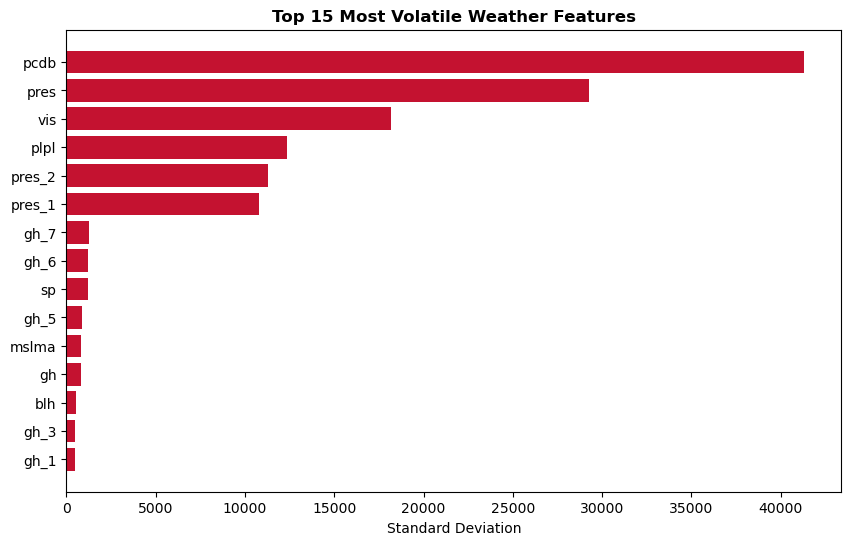

In [14]:
feature_stats = weather_clean.mean(dim=["location","timestamp"]).to_dataframe(name="mean").reset_index()

feature_std = weather_clean.std(dim=["location","timestamp"]).to_dataframe(name="std").reset_index()

feature_max = weather_clean.max(dim=["location","timestamp"]).to_dataframe(name="max").reset_index()

# merge
stats = feature_stats.merge(feature_std, on="feature").merge(feature_max, on="feature")

# Top volatile features
top_std = stats.sort_values("std", ascending=False).head(15)

plt.figure(figsize=(10,6))
plt.barh(top_std["feature"], top_std["std"], color="#C41230")
plt.title("Top 15 Most Volatile Weather Features", weight="bold")
plt.xlabel("Standard Deviation")
plt.gca().invert_yaxis()
plt.show()

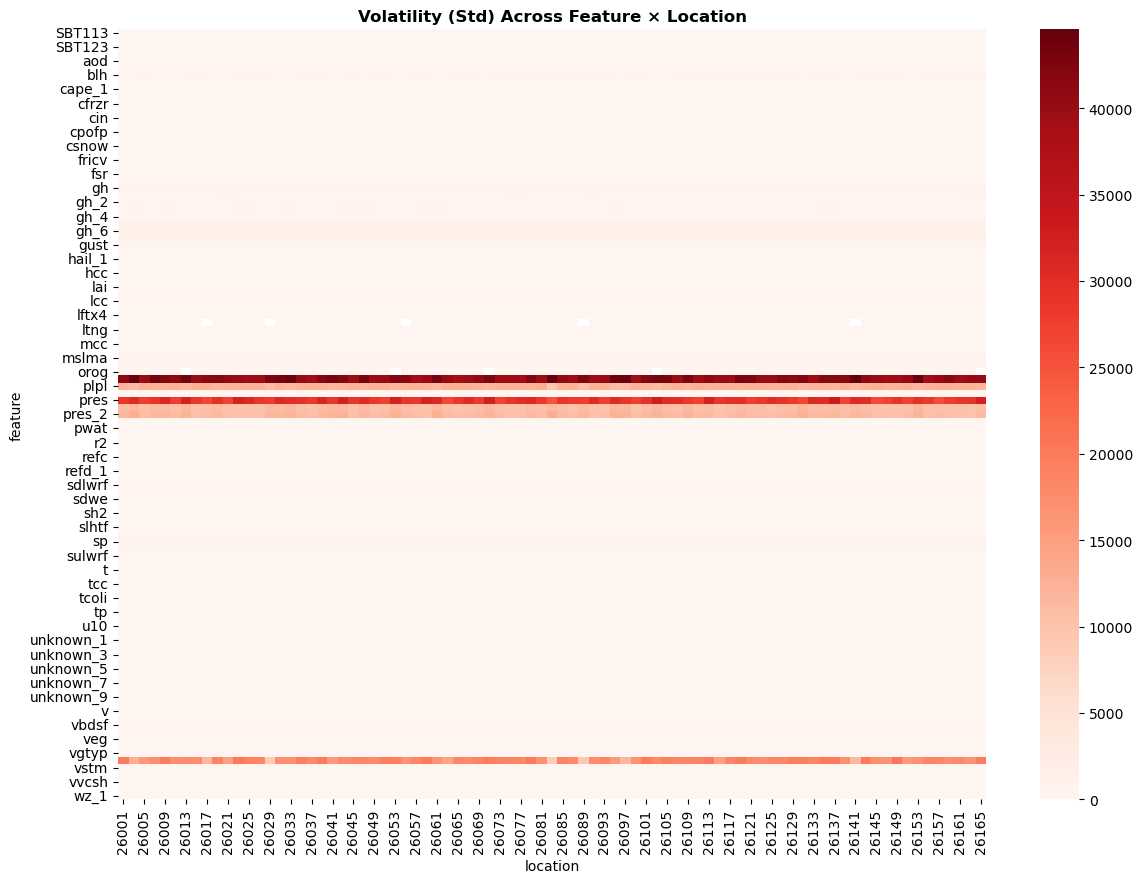

In [15]:
df = weather_clean.to_dataframe(name="value").reset_index()

loc_feature_std = (
    df.groupby(["feature","location"])["value"]
    .std()
    .reset_index()
)


most_volatile_loc = (
    loc_feature_std.sort_values("value", ascending=False)
    .groupby("feature")
    .first()
    .reset_index()
)

most_volatile_loc.head(20)

pivot_std = loc_feature_std.pivot(
    index="feature",
    columns="location",
    values="value"
)


plt.figure(figsize=(14,10))
sns.heatmap(pivot_std, cmap="Reds")
plt.title("Volatility (Std) Across Feature × Location", weight="bold")
plt.show()

3) Power outrange distributed among each region

In [16]:
out_df = ds_train["out"].to_dataframe(name="out").reset_index()
locations = out_df["location"].unique()

fig = go.Figure()

for i, loc in enumerate(locations):
    sub = out_df[out_df["location"] == loc].copy()
    sub = sub[sub["out"] > 0]

    sub["log_out"] = np.log10(sub["out"])

    fig.add_trace(
        go.Histogram(
            x=sub["log_out"],
            nbinsx=50,
            name=str(loc),
            visible=(i == 0),
            opacity=0.85,
            marker=dict(color="#C41230"),
            histnorm="probability density"
        )
    )

buttons = []
for i, loc in enumerate(locations):
    visibility = [False] * len(locations)
    visibility[i] = True

    buttons.append(
        dict(
            label=str(loc),
            method="update",
            args=[
                {"visible": visibility},
                {"title": f"Power Outage Distribution (log10 scale) - Location {loc}"}
            ]
        )
    )

fig.update_layout(
    updatemenus=[dict(buttons=buttons, direction="down")],
    title=f"Power Outage Distribution (log10 scale) - Location {locations[0]}",
    xaxis_title="log10(Outage Value)",
    yaxis_title="Density",
    width=1100,
    height=500
)

fig.show()

In [17]:
total_df = (
    out_df.groupby("location")["out"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig = px.bar(
    total_df,
    x="location",
    y="out",
    title="Total Power Outage by Region"
)

fig.update_traces(marker_color="#C41230")
fig.update_layout(
    xaxis_title="Region",
    yaxis_title="Total Outage",
    width=1200,
    height=500
)

fig.show()

4. Power outrange, tracked and weather features correlations

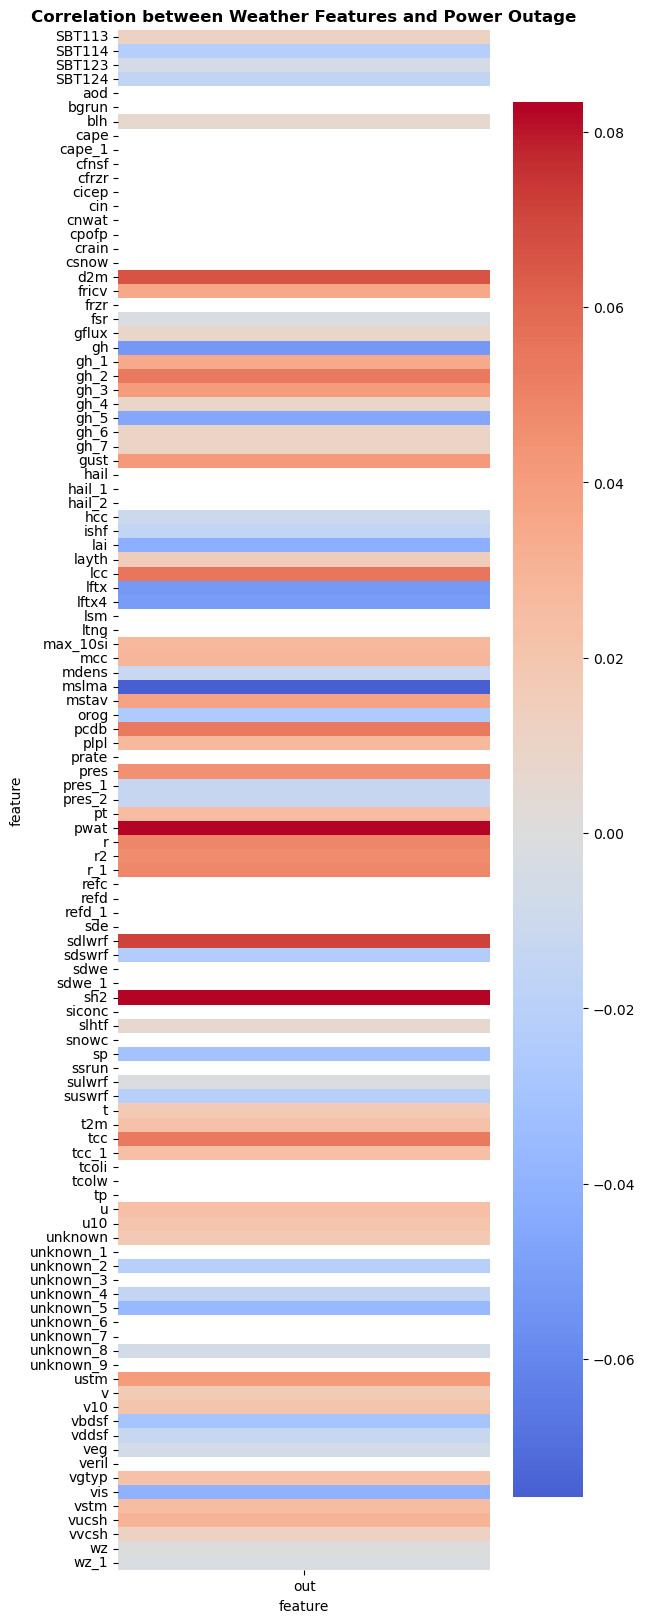

In [18]:
# ===== reshape ====
weather_df = weather_clean.to_dataframe(name="value").reset_index()
out_df = ds_train["out"].to_dataframe(name="out").reset_index()

merged = weather_df.merge(out_df, on=["location","timestamp"])


pivot_df = merged.pivot_table(
    index=["location","timestamp"],
    columns="feature",
    values="value"
)


pivot_df["out"] = merged.groupby(["location","timestamp"])["out"].first().values

# ===== correlation =====
corr = pivot_df.corr()[["out"]].drop("out")

# ===== plot =====
plt.figure(figsize=(6,20))  
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation between Weather Features and Power Outage", weight="bold")
plt.show()

In [21]:
# ===== correlation with out =====
corr_with_out = pivot_df.corr()["out"].drop("out")

threshold = 1e-4
corr_filtered = corr_with_out[abs(corr_with_out) > threshold]

corr_sorted = corr_filtered.reindex(
    corr_filtered.abs().sort_values(ascending=False).index
)
corr_df = corr_sorted.reset_index()
corr_df.columns = ["feature", "correlation"]

# ===== print =====
print("Top 20 features with significant correlation to power outage:\n")
print(corr_df.head(20))

Top 20 features with significant correlation to power outage:

   feature  correlation
0     pwat     0.083374
1      sh2     0.082133
2    mslma    -0.075764
3   sdlwrf     0.071423
4      d2m     0.065565
5      lcc     0.055376
6      tcc     0.053949
7     pcdb     0.053770
8     gh_2     0.053123
9       gh    -0.052853
10    lftx    -0.052629
11   lftx4    -0.051022
12       r     0.049113
13     r_1     0.048463
14      r2     0.046202
15    gh_5    -0.045624
16    pres     0.044849
17    gust     0.041643
18     lai    -0.041351
19    gh_3     0.041075
